# LLM Elicitation — Multi-Run Consistency Analysis

Compares probability estimates (25th, 50th, 75th percentiles) across multiple runs on the same task/step combinations.

**Sections:**
1. **Regular runs** — standard framing (`output_data/runs/*/full_results.json`)
2. **Negation runs** — negated framing (`consistency_checks/output_data_negation/runs/*/full_results.json`)
3. **Comparison** — incoherence score: |p50_reg + p50_neg − 1|

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

PROJECT_ROOT = Path("..").resolve()
RUNS_DIR = PROJECT_ROOT / "output_data" / "runs"
NEG_RUNS_DIR = PROJECT_ROOT / "consistency_checks" / "output_data_negation" / "runs"

## 1. Regular Runs

Standard framing: probability that the attacker *can* complete the step.

In [2]:
records = []

for run_dir in sorted(RUNS_DIR.glob("*")):
    json_path = run_dir / "full_results.json"
    if not json_path.exists():
        continue

    with open(json_path) as f:
        data = json.load(f)

    run_id = run_dir.name
    config = data["run_metadata"]["config_used"]
    model = config["llm_settings"]["model"]

    for step in data["results_per_step"]:
        step_name = step["step_name"]
        for task in step["results_per_task"]:
            task_name = task["task_name"]
            # Use the final Delphi round
            final_round = task["rounds_data"][-1]
            responses = final_round["responses"]

            p25s = [r["percentile_25th"] for r in responses if "percentile_25th" in r]
            p50s = [r["percentile_50th"] for r in responses if "percentile_50th" in r]
            p75s = [r["percentile_75th"] for r in responses if "percentile_75th" in r]

            if not p25s:
                continue

            records.append({
                "run_id": run_id,
                "model": model,
                "step_name": step_name,
                "task_name": task_name,
                "p25": np.mean(p25s),
                "p50": np.mean(p50s),
                "p75": np.mean(p75s),
                "n_experts": len(p25s),
                "final_prob": task["final_aggregated_probability"],
            })

df = pd.DataFrame(records)
print(f"Loaded {len(df)} records from {df['run_id'].nunique()} runs")
display(df[["run_id", "model", "step_name", "task_name", "p25", "p50", "p75", "n_experts"]])

Loaded 24 records from 8 runs


,run_id,model,step_name,task_name,p25,p50,p75,n_experts
0,20260301_165010,claude-sonnet-4-6,TA0001 - Initial Access,Imaginairy,0.610,0.65,0.700,1
1,20260301_165010,claude-sonnet-4-6,TA0002 - Execution,Imaginairy,0.500,0.55,0.600,1
2,20260301_165010,claude-sonnet-4-6,TA0007 - Discovery,Imaginairy,0.850,0.87,0.890,1
3,20260301_165252,claude-sonnet-4-6,TA0001 - Initial Access,Imaginairy,0.600,0.63,0.670,1
4,20260301_165252,claude-sonnet-4-6,TA0002 - Execution,Imaginairy,0.520,0.57,0.620,1
5,20260301_165252,claude-sonnet-4-6,TA0007 - Discovery,Imaginairy,0.830,0.87,0.910,1
6,20260302_201820,claude-sonnet-4-6,TA0001 - Initial Access,Imaginairy,0.610,0.66,0.710,1
7,20260302_201820,claude-sonnet-4-6,TA0002 - Execution,Imaginairy,0.510,0.55,0.600,1
8,20260302_201820,claude-sonnet-4-6,TA0007 - Discovery,Imaginairy,0.860,0.88,0.910,1
9,20260302_202111,claude-sonnet-4-6,TA0001 - Initial Access,Imaginairy,0.610,0.64,0.680,1


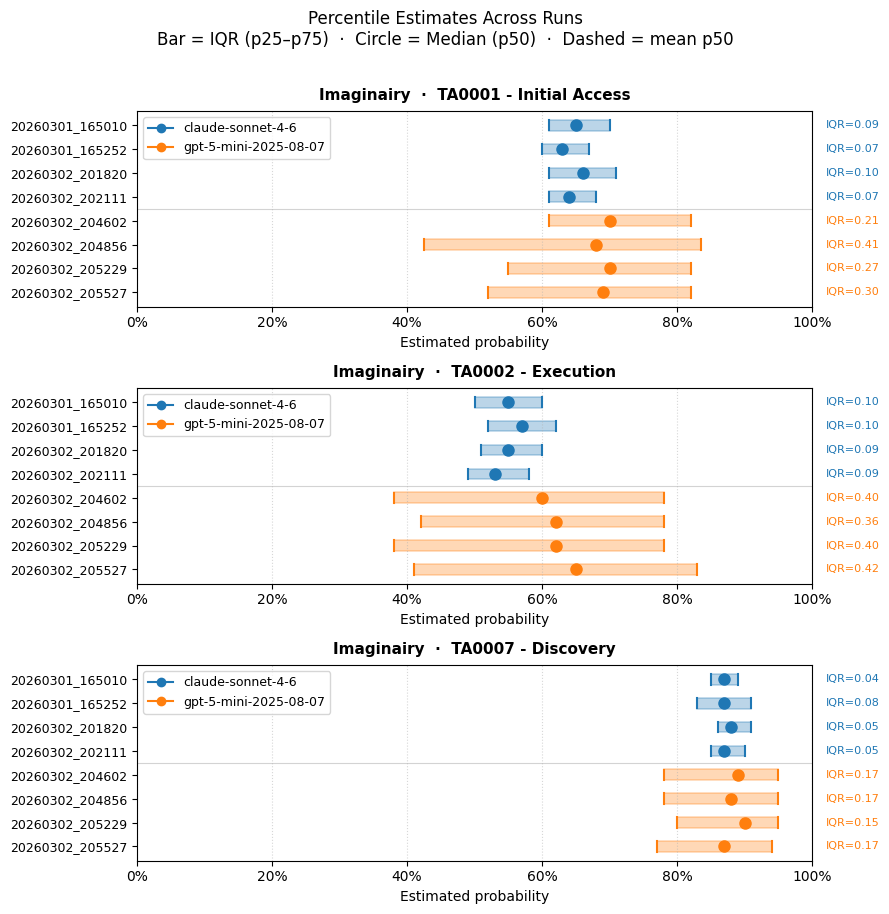

In [3]:
# ── Plot: forest-plot style comparison across runs ──────────────────────────
# One subplot per (task, step). Runs grouped by model; model = colour.

from matplotlib.lines import Line2D

combos = (
    df.groupby(["task_name", "step_name"], sort=True)
    .size()
    .reset_index()[["task_name", "step_name"]]
)
n_plots = len(combos)

# One colour per unique model
all_models = sorted(df["model"].unique())
palette = plt.cm.tab10.colors
model_color = {m: palette[i % len(palette)] for i, m in enumerate(all_models)}

fig, axes = plt.subplots(
    n_plots, 1,
    figsize=(9, 3 * n_plots),
    squeeze=False,
)

for ax, (_, combo) in zip(axes[:, 0], combos.iterrows()):
    task, step = combo["task_name"], combo["step_name"]
    subset = (
        df[(df["task_name"] == task) & (df["step_name"] == step)]
        .sort_values(["model", "run_id"])
        .reset_index(drop=True)
    )

    y_positions = np.arange(len(subset))

    # Thin separator line between model groups
    prev_model = None
    for y, (_, r) in zip(y_positions, subset.iterrows()):
        if prev_model is not None and r["model"] != prev_model:
            ax.axhline(y - 0.5, color="lightgrey", lw=0.8, zorder=0)
        prev_model = r["model"]

    for y, (_, r) in zip(y_positions, subset.iterrows()):
        color = model_color[r["model"]]
        ax.barh(
            y, r["p75"] - r["p25"], left=r["p25"],
            height=0.45, color=color, alpha=0.30, edgecolor=color, linewidth=1.2,
        )
        for px in (r["p25"], r["p75"]):
            ax.plot([px, px], [y - 0.22, y + 0.22], "-", color=color, lw=1.5)
        ax.plot(r["p50"], y, "o", color=color, markersize=8, zorder=3)

    ax.set_yticks(y_positions)
    ax.set_yticklabels([r["run_id"] for _, r in subset.iterrows()], fontsize=9)
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_xlabel("Estimated probability", fontsize=10)
    ax.set_title(f"{task}  \u00b7  {step}", fontsize=11, fontweight="bold", pad=8)
    ax.grid(axis="x", linestyle=":", alpha=0.5)
    ax.invert_yaxis()

    for y, (_, r) in zip(y_positions, subset.iterrows()):
        ax.text(
            1.02, y, f"IQR={r['p75'] - r['p25']:.2f}",
            va="center", ha="left", fontsize=8,
            transform=ax.get_yaxis_transform(),
            color=model_color[r["model"]],
        )

    legend_handles = [
        Line2D([0], [0], color=model_color[m], marker="o", lw=1.5, label=m)
        for m in all_models if m in subset["model"].values
    ]
    ax.legend(handles=legend_handles, fontsize=9, loc="upper left")

fig.suptitle(
    "Percentile Estimates Across Runs\n"
    "Bar = IQR (p25\u2013p75)  \u00b7  Circle = Median (p50)  \u00b7  Dashed = mean p50",
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.show()

In [4]:
# ── Summary statistics: p50 spread across runs per (task, step, model) ──────
summary = (
    df.groupby(["task_name", "step_name", "model"])
    .apply(
        lambda g: pd.Series({
            "n_runs": len(g),
            "p50_mean": g["p50"].mean(),
            "p50_std": g["p50"].std(),
            "p50_cv": g["p50"].std() / g["p50"].mean(),
            "p50_min": g["p50"].min(),
            "p50_max": g["p50"].max(),
            "p50_range": g["p50"].max() - g["p50"].min(),
            "mean_iqr_width": (g["p75"] - g["p25"]).mean(),
        }),
        include_groups=False,
    )
    .reset_index()
)
display(summary.round(4))

,task_name,step_name,model,n_runs,p50_mean,p50_std,p50_cv,p50_min,p50_max,p50_range,mean_iqr_width
0,Imaginairy,TA0001 - Initial Access,claude-sonnet-4-6,4.0,0.6450,0.0129,0.0200,0.63,0.66,0.03,0.0825
1,Imaginairy,TA0001 - Initial Access,gpt-5-mini-2025-08-07,4.0,0.6925,0.0096,0.0138,0.68,0.70,0.02,0.2975
2,Imaginairy,TA0002 - Execution,claude-sonnet-4-6,4.0,0.5500,0.0163,0.0297,0.53,0.57,0.04,0.0950
3,Imaginairy,TA0002 - Execution,gpt-5-mini-2025-08-07,4.0,0.6225,0.0206,0.0331,0.60,0.65,0.05,0.3950
4,Imaginairy,TA0007 - Discovery,claude-sonnet-4-6,4.0,0.8725,0.0050,0.0057,0.87,0.88,0.01,0.0550
5,Imaginairy,TA0007 - Discovery,gpt-5-mini-2025-08-07,4.0,0.8850,0.0129,0.0146,0.87,0.90,0.03,0.1650


{'w1': np.float64(0.011249999999999991),
 'p50_divergence': np.float64(0.01666666666666668),
 'iqr_divergence': np.float64(0.018333333333333274),
 'n_pairs': 6,
 'w1_beta': np.float64(0.017374955999933463)}

,model,step_name,w1,p50_divergence,iqr_divergence,n_pairs,w1_beta
0,claude-sonnet-4-6,TA0001 - Initial Access,0.011250,0.016667,0.018333,6,0.017375
1,claude-sonnet-4-6,TA0002 - Execution,0.014167,0.020000,0.006667,6,0.019203
2,claude-sonnet-4-6,TA0007 - Discovery,0.007917,0.005000,0.020000,6,0.015072
3,gpt-5-mini-2025-08-07,TA0001 - Initial Access,0.028202,0.011667,0.105000,6,0.055343
4,gpt-5-mini-2025-08-07,TA0002 - Execution,0.018437,0.025000,0.030000,6,0.024279
5,gpt-5-mini-2025-08-07,TA0007 - Discovery,0.009167,0.016667,0.010000,6,0.012473


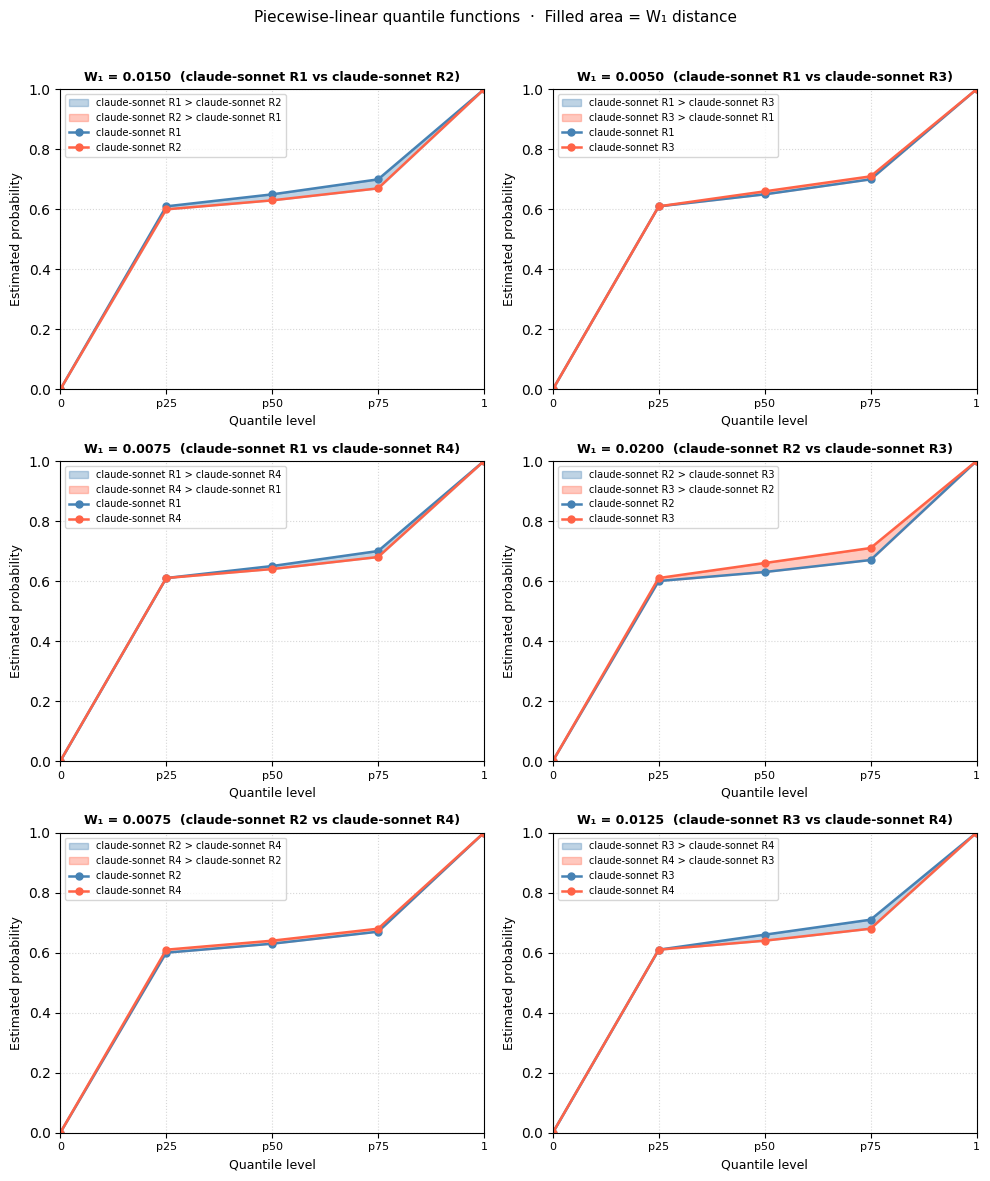

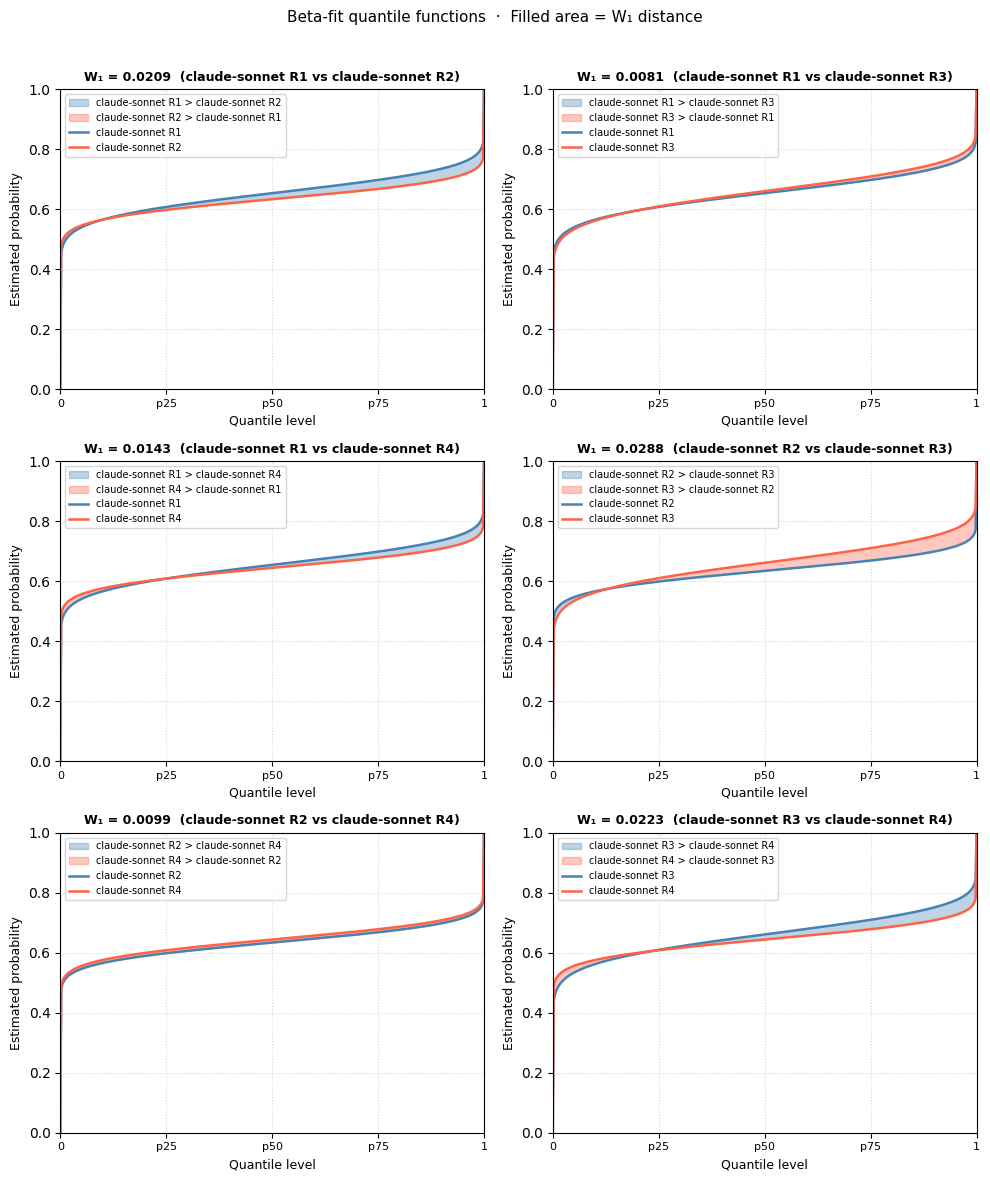

In [5]:
# Compute pairwise comparison metrics for this dataframe
from consistency_metrics import compute_pairwise_metrics, plot_w1_pairs

subset = df[
    (df["model"] == "claude-sonnet-4-6" )  &
    (df["step_name"] == "TA0001 - Initial Access")
]

metrics = compute_pairwise_metrics(subset, include_beta=True)
display(metrics)

#fig = plot_w1_pairs(subset)

# subset = df[0:8]
fig = plot_w1_pairs(subset)
fi2 = plot_w1_pairs(subset, use_beta=True)

# this generates a table of metrics across the different model/task combinations
records = []
for (model, step_name), group in df.groupby(["model", "step_name"]):
    metrics = compute_pairwise_metrics(group, include_beta=True)
    records.append({"model": model, "step_name": step_name, **metrics})

df_metrics = pd.DataFrame(records)
display(df_metrics)


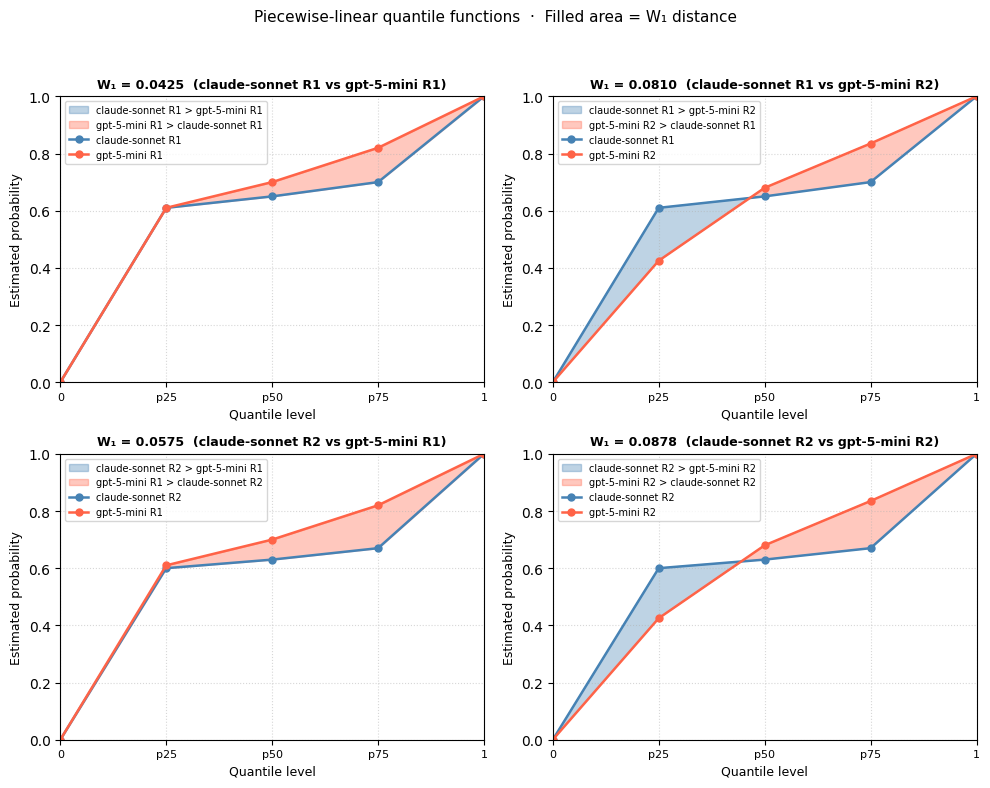

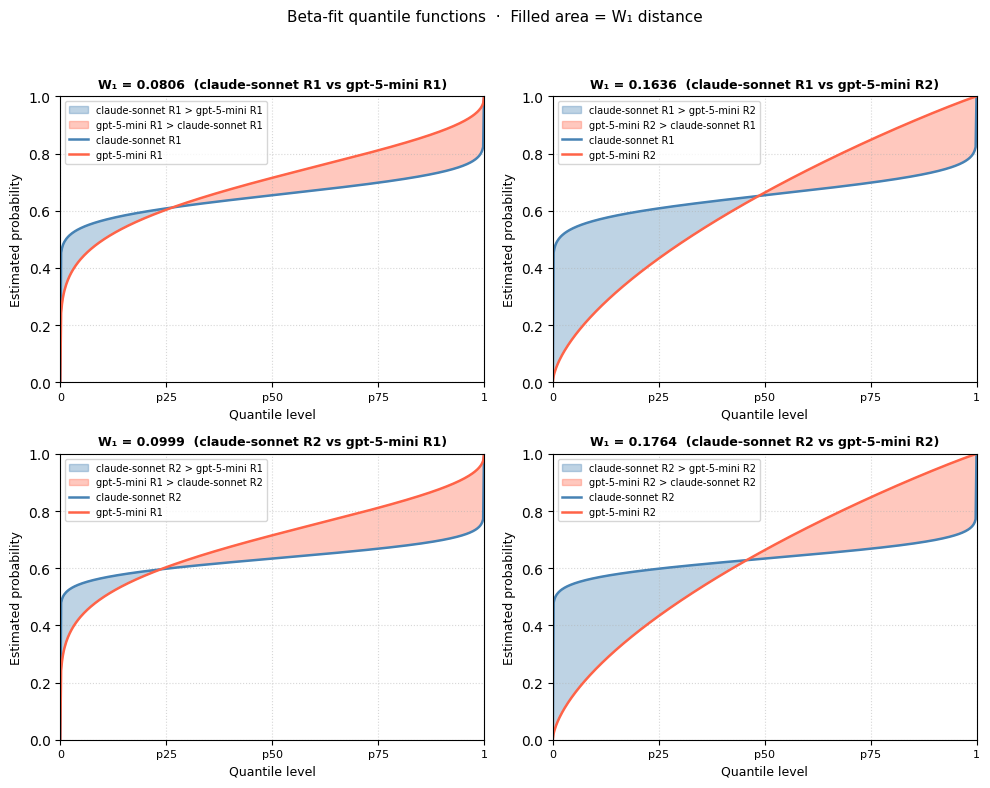

In [6]:
# If you want to make specific comparisons between subsets, can do that too.
df1 = df[(df["model"] == "claude-sonnet-4-6")& (df["step_name"] == "TA0001 - Initial Access")].head(2)
df2 = df[(df["model"] == "gpt-5-mini-2025-08-07")&(df["step_name"] == "TA0001 - Initial Access")].head(2)

fig1 = plot_w1_pairs(df1, df2)  # 2×2 = 4 pairs
fig2 = plot_w1_pairs(df1, df2, use_beta=True) 
# subset = pd.concat([df1, df2]).reset_index(drop=True)
# fig2 = plot_w1_pairs(subset) #all pairs

## 2. Negation Runs

Same analysis as Section 1, but for runs where the question was negated (asking the probability that the attacker *cannot* complete the step).
Data is loaded from `consistency_checks/output_data_negation/runs/*/full_results.json`.

In [7]:
neg_records = []

for run_dir in sorted(NEG_RUNS_DIR.glob("*")):
    json_path = run_dir / "full_results.json"
    if not json_path.exists():
        continue

    with open(json_path) as f:
        data = json.load(f)

    run_id = run_dir.name
    config = data["run_metadata"]["config_used"]
    model = config["llm_settings"]["model"]

    for step in data["results_per_step"]:
        step_name = step["step_name"]
        for task in step["results_per_task"]:
            task_name = task["task_name"]
            final_round = task["rounds_data"][-1]
            responses = final_round["responses"]

            p25s = [r["percentile_25th"] for r in responses
                    if r.get("percentile_25th") is not None]
            p50s = [r["percentile_50th"] for r in responses
                    if r.get("percentile_50th") is not None]
            p75s = [r["percentile_75th"] for r in responses
                    if r.get("percentile_75th") is not None]

            if not p50s:  # skip rows with no valid p50
                continue

            neg_records.append({
                "run_id": run_id,
                "model": model,
                "step_name": step_name,
                "task_name": task_name,
                "p25": np.mean(p25s),
                "p50": np.mean(p50s),
                "p75": np.mean(p75s),
                "n_experts": len(p50s),
                "final_prob": task["final_aggregated_probability"],
            })

df_neg = pd.DataFrame(neg_records)
print(f"Loaded {len(df_neg)} negation records from {df_neg['run_id'].nunique()} runs")
display(df_neg[["run_id", "model", "step_name", "task_name", "p25", "p50", "p75", "n_experts"]])

Loaded 24 negation records from 8 runs


,run_id,model,step_name,task_name,p25,p50,p75,n_experts
0,20260302_195728,claude-sonnet-4-6,TA0001 - Initial Access,Imaginairy,0.320,0.370,0.420,1
1,20260302_195728,claude-sonnet-4-6,TA0002 - Execution,Imaginairy,0.420,0.460,0.510,1
2,20260302_195728,claude-sonnet-4-6,TA0007 - Discovery,Imaginairy,0.100,0.120,0.150,1
3,20260302_200021,claude-sonnet-4-6,TA0001 - Initial Access,Imaginairy,0.270,0.340,0.400,1
4,20260302_200021,claude-sonnet-4-6,TA0002 - Execution,Imaginairy,0.360,0.440,0.520,1
5,20260302_200021,claude-sonnet-4-6,TA0007 - Discovery,Imaginairy,0.090,0.110,0.140,1
6,20260302_201748,claude-sonnet-4-6,TA0001 - Initial Access,Imaginairy,0.300,0.350,0.400,1
7,20260302_201748,claude-sonnet-4-6,TA0002 - Execution,Imaginairy,0.410,0.460,0.510,1
8,20260302_201748,claude-sonnet-4-6,TA0007 - Discovery,Imaginairy,0.090,0.120,0.150,1
9,20260302_202043,claude-sonnet-4-6,TA0001 - Initial Access,Imaginairy,0.280,0.340,0.410,1


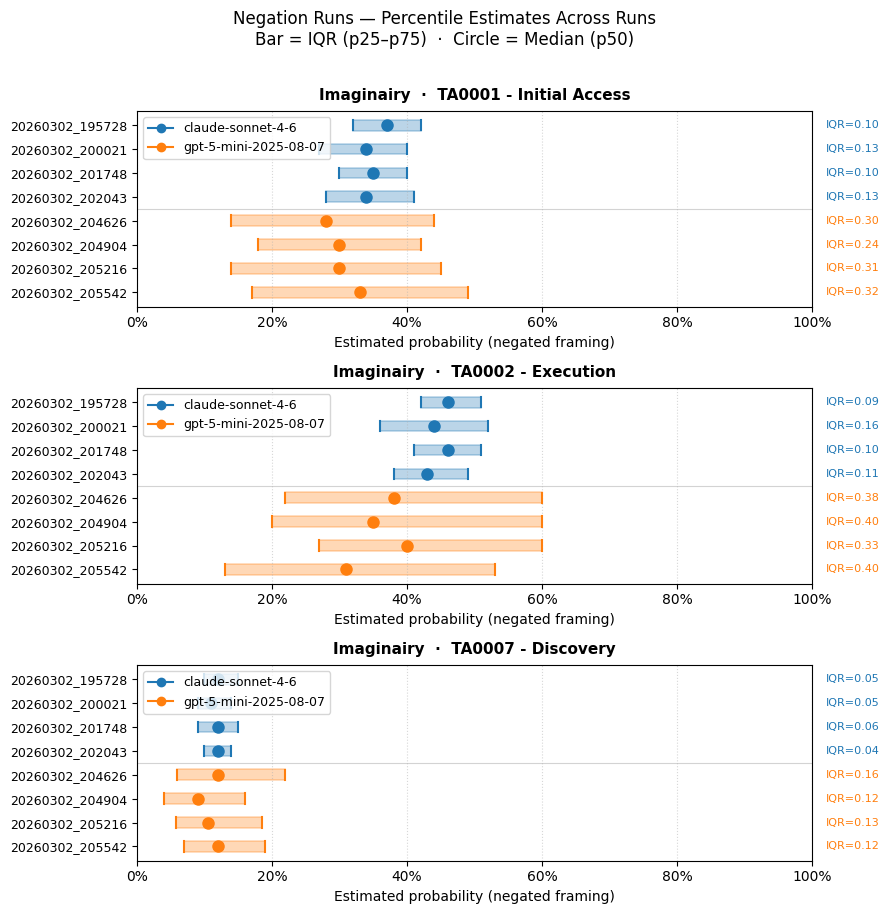

In [8]:
# ── Plot: forest-plot for negation runs ─────────────────────────────────────
# One subplot per (task, step). Runs grouped by model; model = colour.

from matplotlib.lines import Line2D

combos_neg = (
    df_neg.groupby(["task_name", "step_name"], sort=True)
    .size()
    .reset_index()[["task_name", "step_name"]]
)
n_plots_neg = len(combos_neg)

all_models_neg = sorted(df_neg["model"].unique())
palette = plt.cm.tab10.colors
model_color_neg = {m: palette[i % len(palette)] for i, m in enumerate(all_models_neg)}

fig, axes = plt.subplots(
    n_plots_neg, 1,
    figsize=(9, 3 * n_plots_neg),
    squeeze=False,
)

for ax, (_, combo) in zip(axes[:, 0], combos_neg.iterrows()):
    task, step = combo["task_name"], combo["step_name"]
    subset = (
        df_neg[(df_neg["task_name"] == task) & (df_neg["step_name"] == step)]
        .sort_values(["model", "run_id"])
        .reset_index(drop=True)
    )

    y_positions = np.arange(len(subset))

    # Thin separator line between model groups
    prev_model = None
    for y, (_, r) in zip(y_positions, subset.iterrows()):
        if prev_model is not None and r["model"] != prev_model:
            ax.axhline(y - 0.5, color="lightgrey", lw=0.8, zorder=0)
        prev_model = r["model"]

    for y, (_, r) in zip(y_positions, subset.iterrows()):
        color = model_color_neg[r["model"]]
        ax.barh(
            y, r["p75"] - r["p25"], left=r["p25"],
            height=0.45, color=color, alpha=0.30, edgecolor=color, linewidth=1.2,
        )
        for px in (r["p25"], r["p75"]):
            ax.plot([px, px], [y - 0.22, y + 0.22], "-", color=color, lw=1.5)
        ax.plot(r["p50"], y, "o", color=color, markersize=8, zorder=3)

    ax.set_yticks(y_positions)
    ax.set_yticklabels([r["run_id"] for _, r in subset.iterrows()], fontsize=9)
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_xlabel("Estimated probability (negated framing)", fontsize=10)
    ax.set_title(f"{task}  \u00b7  {step}", fontsize=11, fontweight="bold", pad=8)
    ax.grid(axis="x", linestyle=":", alpha=0.5)
    ax.invert_yaxis()

    for y, (_, r) in zip(y_positions, subset.iterrows()):
        ax.text(
            1.02, y, f"IQR={r['p75'] - r['p25']:.2f}",
            va="center", ha="left", fontsize=8,
            transform=ax.get_yaxis_transform(),
            color=model_color_neg[r["model"]],
        )

    legend_handles = [
        Line2D([0], [0], color=model_color_neg[m], marker="o", lw=1.5, label=m)
        for m in all_models_neg if m in subset["model"].values
    ]
    ax.legend(handles=legend_handles, fontsize=9, loc="upper left")

fig.suptitle(
    "Negation Runs — Percentile Estimates Across Runs\n"
    "Bar = IQR (p25\u2013p75)  \u00b7  Circle = Median (p50)",
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.show()

In [9]:
# ── Summary statistics: negation p50 spread across runs per (task, step, model) ──
summary_neg = (
    df_neg.groupby(["task_name", "step_name", "model"])
    .apply(
        lambda g: pd.Series({
            "n_runs": len(g),
            "p50_mean": g["p50"].mean(),
            "p50_std": g["p50"].std(),
            "p50_cv": g["p50"].std() / g["p50"].mean(),
            "p50_range": g["p50"].max() - g["p50"].min(),
            "iqr_width_mean": (g["p75"] - g["p25"]).mean(),
            "iqr_width_std": (g["p75"] - g["p25"]).std(),
        }),
        include_groups=False, # type: ignore
    ) # type: ignore
    .reset_index()
)
display(summary_neg.round(4))

,task_name,step_name,model,n_runs,p50_mean,p50_std,p50_cv,p50_range,iqr_width_mean,iqr_width_std
0,Imaginairy,TA0001 - Initial Access,claude-sonnet-4-6,4.0,0.3500,0.0141,0.0404,0.03,0.1150,0.0173
1,Imaginairy,TA0001 - Initial Access,gpt-5-mini-2025-08-07,4.0,0.3025,0.0206,0.0682,0.05,0.2925,0.0359
2,Imaginairy,TA0002 - Execution,claude-sonnet-4-6,4.0,0.4475,0.0150,0.0335,0.03,0.1150,0.0311
3,Imaginairy,TA0002 - Execution,gpt-5-mini-2025-08-07,4.0,0.3600,0.0392,0.1088,0.09,0.3775,0.0330
4,Imaginairy,TA0007 - Discovery,claude-sonnet-4-6,4.0,0.1175,0.0050,0.0426,0.01,0.0500,0.0082
5,Imaginairy,TA0007 - Discovery,gpt-5-mini-2025-08-07,4.0,0.1088,0.0144,0.1321,0.03,0.1318,0.0191


In [10]:
# Compute pairwise comparison metrics for this dataframe
from consistency_metrics import compute_pairwise_metrics

subset = df_neg[
    (df["model"] == "claude-sonnet-4-6") &
    (df["step_name"] == "TA0001 - Initial Access")
]

metrics = compute_pairwise_metrics(subset, include_beta=True)
display(metrics)


{'w1': np.float64(0.013958333333333317),
 'p50_divergence': np.float64(0.016666666666666646),
 'iqr_divergence': np.float64(0.02),
 'n_pairs': 6,
 'w1_beta': np.float64(0.02112167015438654)}

## 3. Regular vs. Negation Comparison — Incoherence Score

For a coherent model, P(success) + P(cannot succeed) = 1.  
The **incoherence score** for a matched pair of runs is:

$$\text{incoherence} = |p50_{\text{reg}} + p50_{\text{neg}} - 1|$$

We match regular and negation runs on `(task_name, step_name)`, computing the score for every combination of one regular run and one negation run, then report the mean and standard deviation.

In [11]:
# ── Incoherence score: |p50_reg + p50_neg - 1| ──────────────────────────────
# All pairwise combinations of a regular run and a negation run
# for the same (task_name, step_name, model).
df_reg_avg = (
    df.groupby(["task_name", "step_name", "model"])["p50"]
    .agg(list)
    .reset_index()
    .rename(columns={"p50": "p50_reg_list"})
)
df_neg_avg = (
    df_neg.groupby(["task_name", "step_name", "model"])["p50"]
    .agg(list)
    .reset_index()
    .rename(columns={"p50": "p50_neg_list"})
)

merged = df_reg_avg.merge(df_neg_avg, on=["task_name", "step_name", "model"])

pair_records = []
for _, row in merged.iterrows():
    for p_reg in row["p50_reg_list"]:
        for p_neg in row["p50_neg_list"]:
            score = abs(p_reg + p_neg - 1)
            pair_records.append({
                "task_name": row["task_name"],
                "step_name": row["step_name"],
                "model": row["model"],
                "p50_reg": p_reg,
                "p50_neg": p_neg,
                "sum": p_reg + p_neg,
                "incoherence": score,
            })

df_pairs = pd.DataFrame(pair_records)

# print("=== All matched pairs ===")
# display(df_pairs.round(4))

print("\n=== Incoherence summary per (task, step, model) ===")
incoherence_by_combo = (
    df_pairs.groupby(["task_name", "step_name", "model"])
    .agg(
        n_pairs=("incoherence", "count"),
        incoherence_mean=("incoherence", "mean"),
        incoherence_std=("incoherence", "std"),
        sum_mean=("sum", "mean"),
        sum_std=("sum", "std"),
    )
    .reset_index()
)
display(incoherence_by_combo.round(4))

overall_mean = df_pairs["incoherence"].mean()
overall_std  = df_pairs["incoherence"].std()
print(f"\n=== Overall incoherence ===")
print(f"  Mean : {overall_mean:.4f}")
print(f"  Std  : {overall_std:.4f}")
print(f"  (n={len(df_pairs)} pairs)")


=== Incoherence summary per (task, step, model) ===


,task_name,step_name,model,n_pairs,incoherence_mean,incoherence_std,sum_mean,sum_std
0,Imaginairy,TA0001 - Initial Access,claude-sonnet-4-6,16,0.0138,0.0109,0.9950,0.0171
1,Imaginairy,TA0001 - Initial Access,gpt-5-mini-2025-08-07,16,0.0163,0.0126,0.9950,0.0203
2,Imaginairy,TA0002 - Execution,claude-sonnet-4-6,16,0.0163,0.0109,0.9975,0.0198
3,Imaginairy,TA0002 - Execution,gpt-5-mini-2025-08-07,16,0.0325,0.0277,0.9825,0.0396
4,Imaginairy,TA0007 - Discovery,claude-sonnet-4-6,16,0.0100,0.0063,0.9900,0.0063
5,Imaginairy,TA0007 - Discovery,gpt-5-mini-2025-08-07,16,0.0144,0.0109,0.9938,0.0173



=== Overall incoherence ===
  Mean : 0.0172
  Std  : 0.0161
  (n=96 pairs)


{'w1': np.float64(0.014687499999999973),
 'p50_divergence': np.float64(0.014999999999999958),
 'iqr_divergence': np.float64(0.03499999999999992),
 'n_pairs': 4,
 'w1_beta': np.float64(0.026937894567227012)}

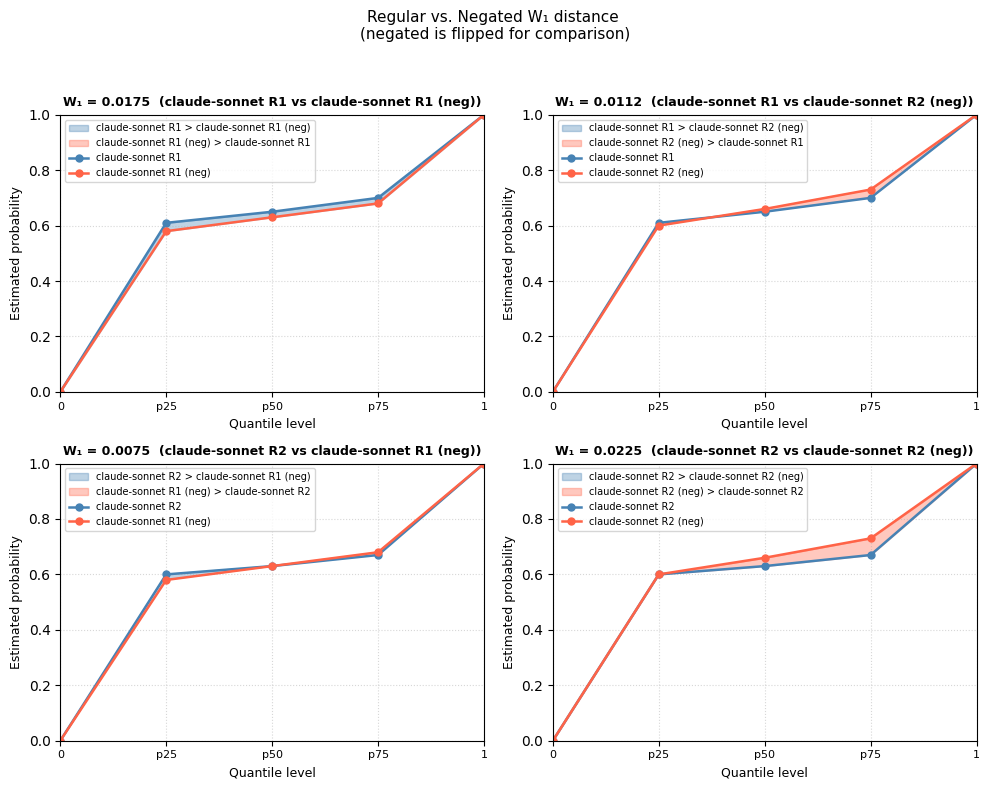

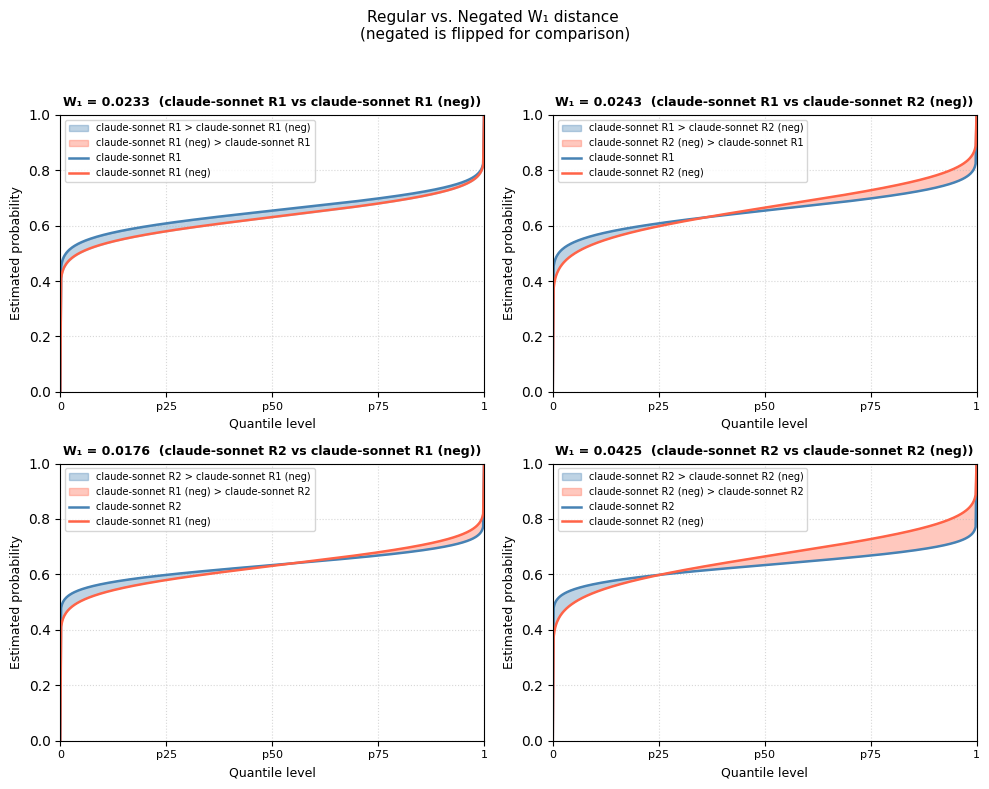

In [12]:
# Here I want to compare the negation model to the negated version, which means I need to flip one of them.
# I think it's easiest to do this by flipping the predictions directly instead of inside the script.
df1 = df[(df["model"] == "claude-sonnet-4-6")& (df["step_name"] == "TA0001 - Initial Access")].head(2)
df2 = df_neg[(df_neg["model"] == "claude-sonnet-4-6")&(df["step_name"] == "TA0001 - Initial Access")].head(2)
df2 = df2.copy()
df2[["p25", "p50", "p75"]] = 1 - df2[["p75", "p50", "p25"]].values


metrics = compute_pairwise_metrics(df1, df2, include_beta=True)
display(metrics)
fig1 = plot_w1_pairs(df1, df2, use_beta=False, label2="neg")
fig1.suptitle("Regular vs. Negated W₁ distance \n(negated is flipped for comparison)", fontsize=11)
fig1.tight_layout(rect=(0, 0, 1, 0.95))

fig2 = plot_w1_pairs(df1, df2, use_beta=True, label2="neg")
fig2.suptitle("Regular vs. Negated W₁ distance \n(negated is flipped for comparison)", fontsize=11)
fig2.tight_layout(rect=(0, 0, 1, 0.95))

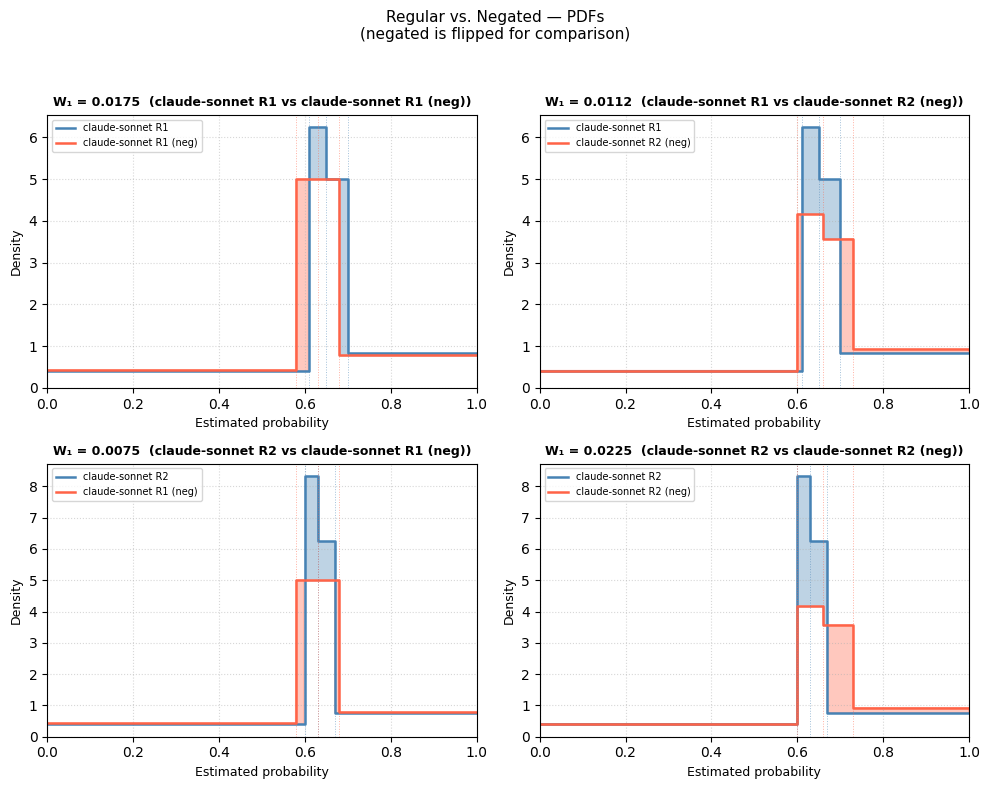

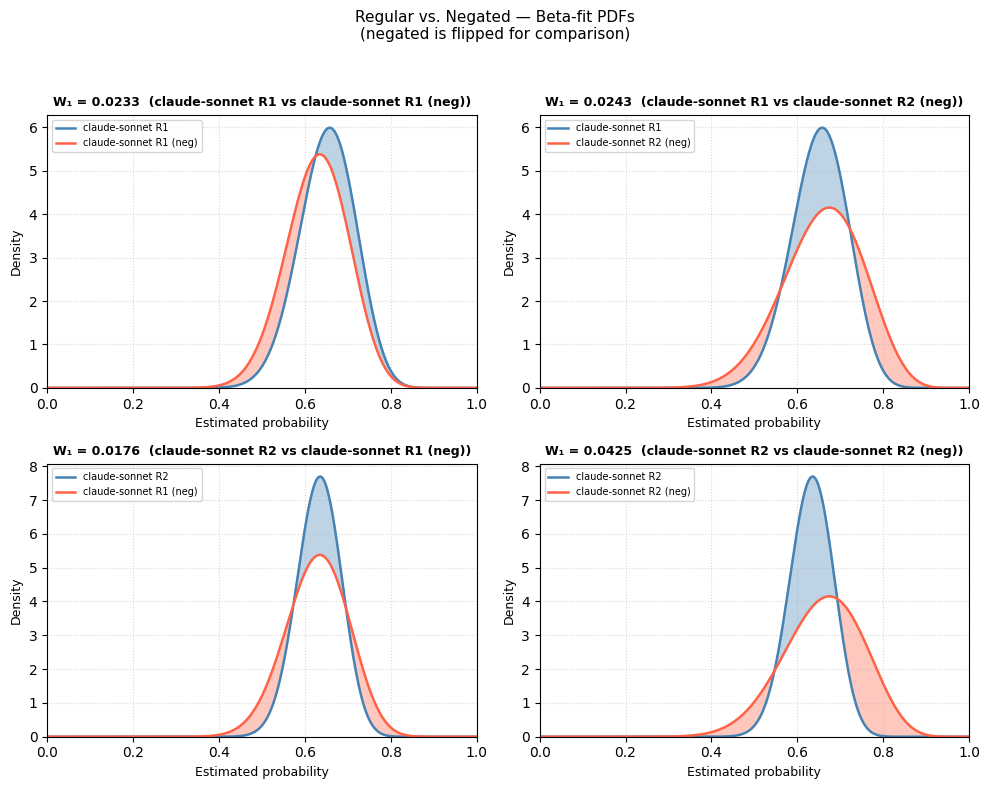

In [13]:
from consistency_metrics import plot_pdf_pairs

fig3 = plot_pdf_pairs(df1, df2, use_beta=False, label2="neg")
fig3.suptitle("Regular vs. Negated — PDFs\n(negated is flipped for comparison)", fontsize=11)
fig3.tight_layout(rect=(0, 0, 1, 0.95))

fig4 = plot_pdf_pairs(df1, df2, use_beta=True, label2="neg")
fig4.suptitle("Regular vs. Negated — Beta-fit PDFs\n(negated is flipped for comparison)", fontsize=11)
fig4.tight_layout(rect=(0, 0, 1, 0.95))

In [14]:
records = []
df2 = df_neg.copy()
df2[["p25", "p50", "p75"]] = 1 - df_neg[["p75", "p50", "p25"]].values
for (model, step_name), group1 in df.groupby(["model", "step_name"]):
    group2 = df2[(df2["model"] == model) & (df2["step_name"] == step_name)]
    if group2.empty:
        continue
    metrics = compute_pairwise_metrics(group1, group2, include_beta=False)
    records.append({"model": model, "step_name": step_name, **metrics})

df_cross_metrics = pd.DataFrame(records)
display(df_cross_metrics)


,model,step_name,w1,p50_divergence,iqr_divergence,n_pairs
0,claude-sonnet-4-6,TA0001 - Initial Access,0.012799,0.013750,0.0325,16
1,claude-sonnet-4-6,TA0002 - Execution,0.013620,0.016250,0.0225,16
2,claude-sonnet-4-6,TA0007 - Discovery,0.006719,0.010000,0.0125,16
3,gpt-5-mini-2025-08-07,TA0001 - Initial Access,0.023540,0.016250,0.0650,16
4,gpt-5-mini-2025-08-07,TA0002 - Execution,0.026531,0.032500,0.0300,16
5,gpt-5-mini-2025-08-07,TA0007 - Discovery,0.013669,0.014375,0.0345,16


## 4. Confidence Interval Width Comparison

Compares IQR width (p75 − p25) across runs **within** each framing and **between** framings.

- **Within regular / within negation**: does the model produce consistently wide or narrow intervals run-to-run?
- **Across framings**: does regular framing produce wider or narrower intervals than the negated framing?

=== IQR width summary per (task, step, model, framing) ===


,task_name,step_name,model,framing,n_runs,iqr_mean,iqr_std,iqr_min,iqr_max
0,Imaginairy,TA0001 - Initial Access,claude-sonnet-4-6,negation,4,0.1150,0.0173,0.10,0.13
1,Imaginairy,TA0001 - Initial Access,claude-sonnet-4-6,regular,4,0.0825,0.0150,0.07,0.10
2,Imaginairy,TA0001 - Initial Access,gpt-5-mini-2025-08-07,negation,4,0.2925,0.0359,0.24,0.32
3,Imaginairy,TA0001 - Initial Access,gpt-5-mini-2025-08-07,regular,4,0.2975,0.0838,0.21,0.41
4,Imaginairy,TA0002 - Execution,claude-sonnet-4-6,negation,4,0.1150,0.0311,0.09,0.16
5,Imaginairy,TA0002 - Execution,claude-sonnet-4-6,regular,4,0.0950,0.0058,0.09,0.10
6,Imaginairy,TA0002 - Execution,gpt-5-mini-2025-08-07,negation,4,0.3775,0.0330,0.33,0.40
7,Imaginairy,TA0002 - Execution,gpt-5-mini-2025-08-07,regular,4,0.3950,0.0252,0.36,0.42
8,Imaginairy,TA0007 - Discovery,claude-sonnet-4-6,negation,4,0.0500,0.0082,0.04,0.06
9,Imaginairy,TA0007 - Discovery,claude-sonnet-4-6,regular,4,0.0550,0.0173,0.04,0.08


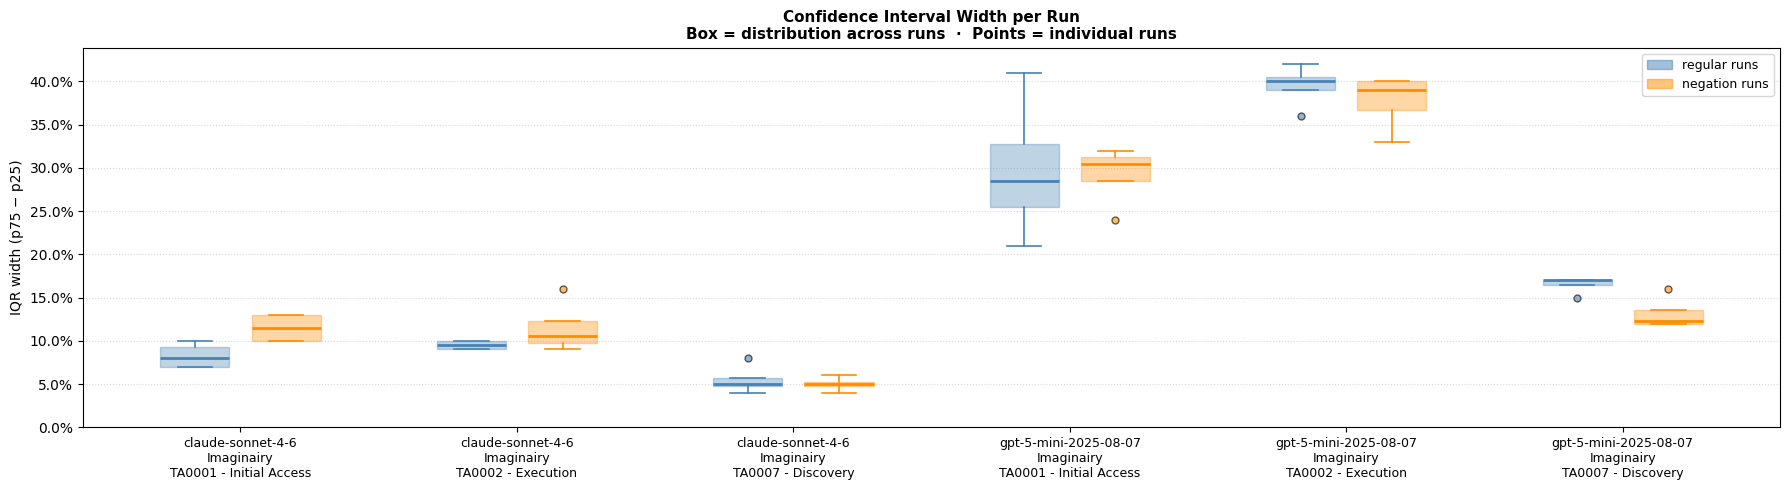


=== IQR width: regular vs. negation (mean across runs) ===


,task_name,step_name,model,iqr_reg,iqr_neg,iqr_diff,wider_framing
0,Imaginairy,TA0001 - Initial Access,claude-sonnet-4-6,0.0825,0.1150,0.0325,negation
1,Imaginairy,TA0001 - Initial Access,gpt-5-mini-2025-08-07,0.2975,0.2925,-0.0050,regular
2,Imaginairy,TA0002 - Execution,claude-sonnet-4-6,0.0950,0.1150,0.0200,negation
3,Imaginairy,TA0002 - Execution,gpt-5-mini-2025-08-07,0.3950,0.3775,-0.0175,regular
4,Imaginairy,TA0007 - Discovery,claude-sonnet-4-6,0.0550,0.0500,-0.0050,regular
5,Imaginairy,TA0007 - Discovery,gpt-5-mini-2025-08-07,0.1650,0.1318,-0.0332,regular


In [15]:
# ── Build unified IQR-width dataframe ───────────────────────────────────────
df_iqr_reg = df.copy()
df_iqr_reg["iqr_width"] = df_iqr_reg["p75"] - df_iqr_reg["p25"]
df_iqr_reg["framing"] = "regular"

df_iqr_neg = df_neg.copy()
df_iqr_neg["iqr_width"] = df_iqr_neg["p75"] - df_iqr_neg["p25"]
df_iqr_neg["framing"] = "negation"

df_iqr = pd.concat([df_iqr_reg, df_iqr_neg], ignore_index=True)
df_iqr["task_step"] = df_iqr["model"] + "\n" + df_iqr["task_name"] + "\n" + df_iqr["step_name"]

# ── Summary table: mean/std IQR per (task, step, model, framing) ─────────────
summary_iqr = (
    df_iqr.groupby(["task_name", "step_name", "model", "framing"])
    .agg(
        n_runs=("iqr_width", "count"),
        iqr_mean=("iqr_width", "mean"),
        iqr_std=("iqr_width", "std"),
        iqr_min=("iqr_width", "min"),
        iqr_max=("iqr_width", "max"),
    )
    .reset_index()
)
print("=== IQR width summary per (task, step, model, framing) ===")
display(summary_iqr.round(4))

# ── Plot 1: Box plots of IQR width, grouped by (task/step/model), coloured by framing ──
from matplotlib.patches import Patch

task_steps = sorted(df_iqr["task_step"].unique())
framings = ["regular", "negation"]
framing_colors = {"regular": "steelblue", "negation": "darkorange"}
n_ts = len(task_steps)

box_w = 0.25
gap = 0.08
offsets = [-(box_w / 2 + gap / 2), box_w / 2 + gap / 2]

fig, ax = plt.subplots(figsize=(max(7, 3 * n_ts), 5))

for fi, framing in enumerate(framings):
    color = framing_colors[framing]
    sub = df_iqr[df_iqr["framing"] == framing]

    positions = [ts_idx + offsets[fi] for ts_idx in range(n_ts)]
    data = [sub[sub["task_step"] == ts]["iqr_width"].values for ts in task_steps]

    ax.boxplot(
        data,
        positions=positions,
        widths=box_w,
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.35, color=color),
        medianprops=dict(color=color, linewidth=2),
        whiskerprops=dict(color=color, linewidth=1.2),
        capprops=dict(color=color, linewidth=1.2),
        flierprops=dict(marker="o", markerfacecolor=color, markersize=5, alpha=0.6),
        manage_ticks=False,
    )

    # # Overlay individual run points
    # rng = np.random.default_rng(seed=0)
    # for ts_idx, ts in enumerate(task_steps):
    #     ys = sub[sub["task_step"] == ts]["iqr_width"].values
    #     jitter = rng.uniform(-0.04, 0.04, size=len(ys))
    #     ax.scatter(
    #         positions[ts_idx] + jitter, ys,
    #         color=color, s=55, zorder=4, alpha=0.9, edgecolors="white", linewidths=0.5,
    #     )

legend_elements = [
    Patch(facecolor=framing_colors[f], alpha=0.5, edgecolor=framing_colors[f], label=f"{f} runs")
    for f in framings
]
ax.legend(handles=legend_elements, fontsize=9, loc="upper right")

ax.set_xticks(range(n_ts))
ax.set_xticklabels(task_steps, fontsize=9)
ax.set_ylabel("IQR width (p75 − p25)", fontsize=10)
ax.set_title(
    "Confidence Interval Width per Run\n"
    "Box = distribution across runs  ·  Points = individual runs",
    fontsize=11, fontweight="bold",
)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.grid(axis="y", linestyle=":", alpha=0.5)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

# ── Plot 2: Scatter — mean IQR (regular) vs mean IQR (negation) ─────────────
iqr_reg_mean = (
    df_iqr[df_iqr["framing"] == "regular"]
    .groupby(["task_name", "step_name", "model"])["iqr_width"]
    .mean()
    .rename("iqr_reg")
)
iqr_neg_mean = (
    df_iqr[df_iqr["framing"] == "negation"]
    .groupby(["task_name", "step_name", "model"])["iqr_width"]
    .mean()
    .rename("iqr_neg")
)
df_cross = pd.concat([iqr_reg_mean, iqr_neg_mean], axis=1).dropna().reset_index()

# ── Numerical cross-framing comparison ──────────────────────────────────────
df_cross["wider_framing"] = np.where(
    df_cross["iqr_reg"] > df_cross["iqr_neg"], "regular",
    np.where(df_cross["iqr_neg"] > df_cross["iqr_reg"], "negation", "equal"),
)
df_cross["iqr_diff"] = df_cross["iqr_neg"] - df_cross["iqr_reg"]
print("\n=== IQR width: regular vs. negation (mean across runs) ===")
display(df_cross[["task_name", "step_name", "model", "iqr_reg", "iqr_neg", "iqr_diff", "wider_framing"]].round(4))

## KL vs W1 demo

=== Metrics ===
KL(p||q_near) = 0.001213
KL(p||q_fat ) = 0.024991
W1(p, q_near) = 0.053070
W1(p, q_fat ) = 0.100572


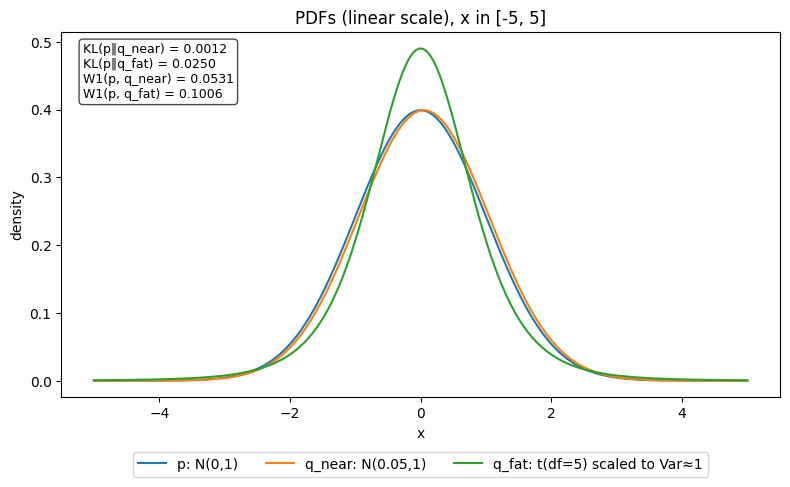

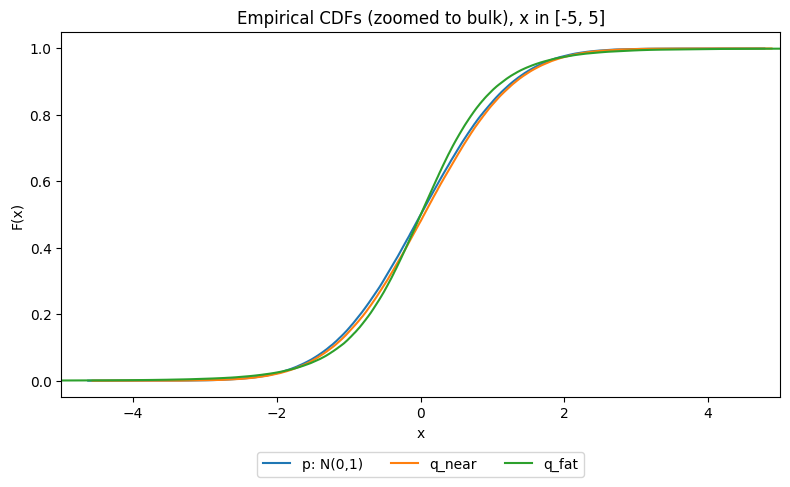

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, t

# -------------------------
# Metrics
# -------------------------
def kl_mc(p_logpdf, q_logpdf, sampler, n=800_000, seed=0):
    rng = np.random.default_rng(seed)
    x = sampler(rng, n)
    return float(np.mean(p_logpdf(x) - q_logpdf(x)))

def w1_1d_samples(x, y):
    # 1D empirical W1: mean absolute difference between sorted samples
    x = np.sort(x)
    y = np.sort(y)
    return float(np.mean(np.abs(x - y)))

# -------------------------
# "Tail-hole" construction
# -------------------------
def make_q_hole(a=3.5, eps=1e-6):
    # q(x) ∝ p(x) * w(x), where w(x)=eps in tails, 1 otherwise; renormalize
    ptail = 2 * (1 - norm.cdf(a))
    Z = (1 - ptail) * 1.0 + ptail * eps

    def q_logpdf(x):
        x = np.asarray(x)
        logp = norm.logpdf(x)
        w = np.where(np.abs(x) > a, eps, 1.0)
        return logp + np.log(w) - np.log(Z)

    def q_sampler(rng, n):
        # Rejection sampling from p with acceptance prob w(x)
        out = []
        need = n
        while need > 0:
            x = rng.normal(size=max(1000, need * 3))
            u = rng.uniform(size=x.size)
            w = np.where(np.abs(x) > a, eps, 1.0)
            keep = x[u < w]
            out.append(keep)
            got = sum(len(k) for k in out)
            need = n - got
        return np.concatenate(out)[:n]

    return q_logpdf, q_sampler

# -------------------------
# Distributions
# -------------------------
p = norm(loc=0, scale=1)
p_logpdf = p.logpdf
p_sampler = lambda rng, n: rng.normal(loc=0, scale=1, size=n)

# Similar Gaussian
q_near = norm(loc=0.05, scale=1.0)
q_near_logpdf = q_near.logpdf
q_near_sampler = lambda rng, n: rng.normal(loc=0.05, scale=1.0, size=n)

# Heavy-tailed t (variance ~1)
# df = 3
# scale = np.sqrt((df - 2) / df)  # Var = df/(df-2)*scale^2 -> 1
# q_fat = t(df=df, loc=0.0, scale=scale)
df = 5
scale = np.sqrt((df - 2) / df)   # keeps Var≈1
q_fat = t(df=df, loc=0.0, scale=scale)
q_fat_logpdf = q_fat.logpdf
q_fat_sampler = lambda rng, n: q_fat.rvs(size=n, random_state=rng)

# Tail-hole q
a = 3.5
eps = 1e-10
q_hole_logpdf, q_hole_sampler = make_q_hole(a=a, eps=eps)

# -------------------------
# Compute metrics
# -------------------------
seed = 123
kl_n = 800_000
w1_n = 200_000

kl_p_qnear = kl_mc(p_logpdf, q_near_logpdf, p_sampler, n=kl_n, seed=seed)
kl_p_qfat  = kl_mc(p_logpdf, q_fat_logpdf,  p_sampler, n=kl_n, seed=seed)
kl_p_qhole = kl_mc(p_logpdf, q_hole_logpdf, p_sampler, n=kl_n, seed=seed)

rng = np.random.default_rng(seed)
x_w = p_sampler(rng, w1_n)
y_near = q_near_sampler(rng, w1_n)
y_fat  = q_fat_sampler(rng, w1_n)
y_hole = q_hole_sampler(rng, w1_n)

w1_p_qnear = w1_1d_samples(x_w, y_near)
w1_p_qfat  = w1_1d_samples(x_w, y_fat)
w1_p_qhole = w1_1d_samples(x_w, y_hole)

print("=== Metrics ===")
print(f"KL(p||q_near) = {kl_p_qnear:.6f}")
print(f"KL(p||q_fat ) = {kl_p_qfat:.6f}")
#print(f"KL(p||q_hole) = {kl_p_qhole:.6f}  (a={a}, eps={eps})")
print(f"W1(p, q_near) = {w1_p_qnear:.6f}")
print(f"W1(p, q_fat ) = {w1_p_qfat:.6f}")
#print(f"W1(p, q_hole) = {w1_p_qhole:.6f}")

# -------------------------
# Plots
# -------------------------
# 1) PDFs on linear scale (zoomed-in)
xs = np.linspace(-5, 5, 2000)
p_pdf = p.pdf(xs)
qnear_pdf = q_near.pdf(xs)
qfat_pdf = q_fat.pdf(xs)
qhole_pdf = np.exp(q_hole_logpdf(xs))

plt.figure(figsize=(8, 5))
plt.plot(xs, p_pdf, label="p: N(0,1)")
plt.plot(xs, qnear_pdf, label="q_near: N(0.05,1)")
plt.plot(xs, qfat_pdf, label=f"q_fat: t(df={df}) scaled to Var≈1")
#plt.plot(xs, qhole_pdf, label=f"q_hole: tail suppressed (a={a}, eps={eps})")
plt.title("PDFs (linear scale), x in [-5, 5]")
plt.xlabel("x")
plt.ylabel("density")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.13), ncol=3)
plt.tight_layout()
ax = plt.gca()
ax.text(
    0.03, 0.97,
    f"KL(p‖q_near) = {kl_p_qnear:.4f}\nKL(p‖q_fat) = {kl_p_qfat:.4f}\nW1(p, q_near) = {w1_p_qnear:.4f}\nW1(p, q_fat) = {w1_p_qfat:.4f}",
    transform=ax.transAxes,
    va='top', ha='left',
    fontsize=9,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7)
)
plt.show()

# 3) Empirical CDFs (bulk similarity)
def ecdf(samples):
    s = np.sort(samples)
    y = np.arange(1, len(s) + 1) / len(s)
    return s, y

n_cdf = 200_000
rng = np.random.default_rng(seed + 1)
x = p_sampler(rng, n_cdf)
y1 = q_near_sampler(rng, n_cdf)
y2 = q_fat_sampler(rng, n_cdf)
y3 = q_hole_sampler(rng, n_cdf)

sx, Fx = ecdf(x)
s1, F1 = ecdf(y1)
s2, F2 = ecdf(y2)
s3, F3 = ecdf(y3)

plt.figure(figsize=(8, 5))
plt.plot(sx, Fx, label="p: N(0,1)")
plt.plot(s1, F1, label="q_near")
plt.plot(s2, F2, label="q_fat")
#plt.plot(s3, F3, label="q_hole")
plt.xlim(-5, 5)
plt.title("Empirical CDFs (zoomed to bulk), x in [-5, 5]")
plt.xlabel("x")
plt.ylabel("F(x)")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.13), ncol=3)
plt.tight_layout()
plt.show()
